# HOMEWORK 5

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [154]:
from typing import Tuple

import cv2
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

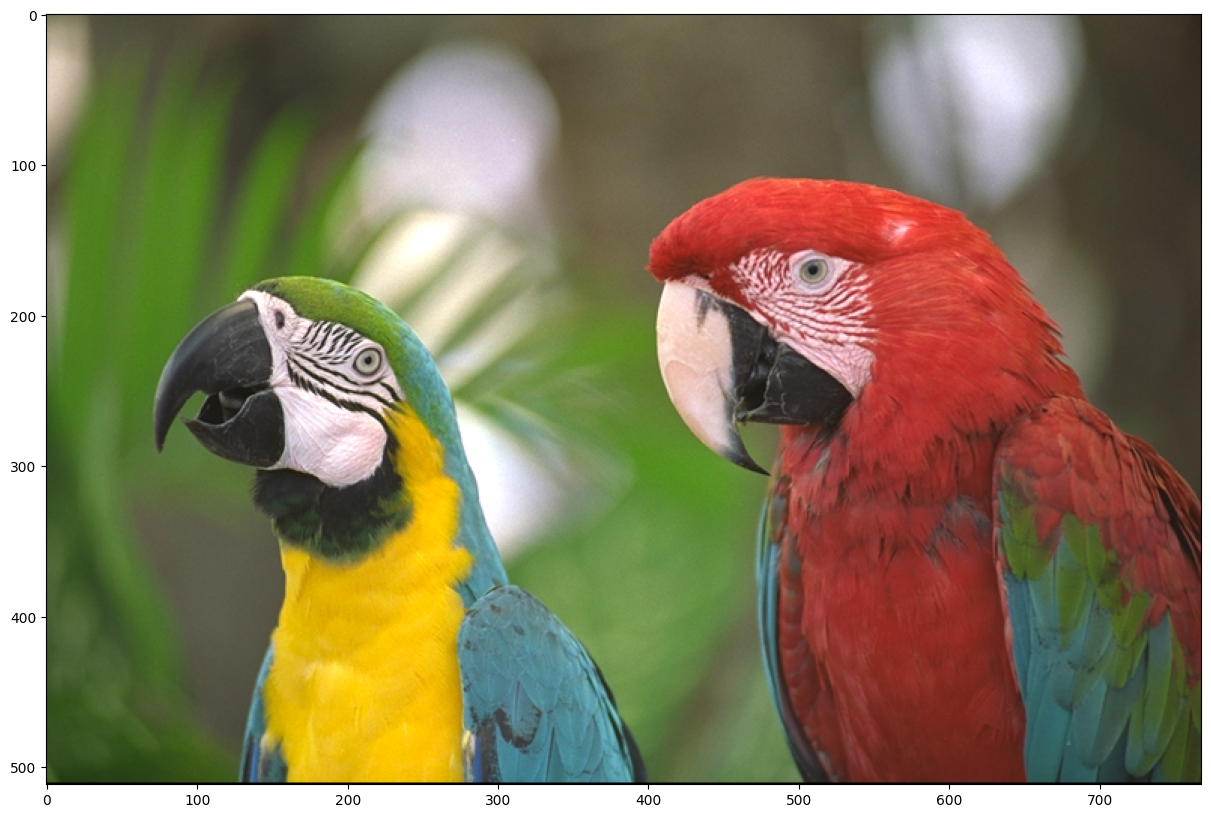

In [155]:
# Load image
img = cv2.imread('../data/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [181]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

colors_bw = np.array([[0, 0, 0],
                      [255, 255, 255]])

Using the colour pallette, let's quantize the original image.

In [165]:
def quantize_to_palette(img: np.ndarray,
                        colors: np.ndarray) -> np.ndarray:
    """
    Quantize an image to a given palette.

    Parameters
    ----------
    img : (H, W, C) float32
        Source RGB image.
    colors : (K, C) float32
        Target palette (each row is a color).

    Returns
    -------
    quantized : (H, W, C) float32
        Quantized image using the palette.
    """
    palette = colors.astype(np.float32)

    rows, cols, channels = img.shape
    quantized = np.zeros_like(img)

    for r in range(rows):
        for c in range(cols):
            # Extract the original pixel value
            pixel = img[r, c, :]
            diffs = palette - pixel[None, :]
            dists = np.linalg.norm(diffs, axis=1)
            # Find the closest colour from the pallette (using absolute value/Euclidean distance)
            # Note: You may need more than one line of code here
            new_pixel = colors[int(np.argmin(dists))]

            # Apply quantization
            quantized[r, c, :] = new_pixel

    return quantized

In [166]:
# Cast the image to float
img = img.astype(np.float32)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

quantized = quantize_to_palette(img, colors)

# Apply quantization
# for r in range(rows):
#     for c in range(cols):
#         # Extract the original pixel value
#         pixel = img[r, c, :]
#         diffs = palette - pixel[None, :]
#         dists = np.linalg.norm(diffs, axis=1)
#         # Find the closest colour from the pallette (using absolute value/Euclidean distance)
#         # Note: You may need more than one line of code here
#         new_pixel = colors[int(np.argmin(dists))]
#
#         # Apply quantization
#         quantized[r, c, :] = new_pixel

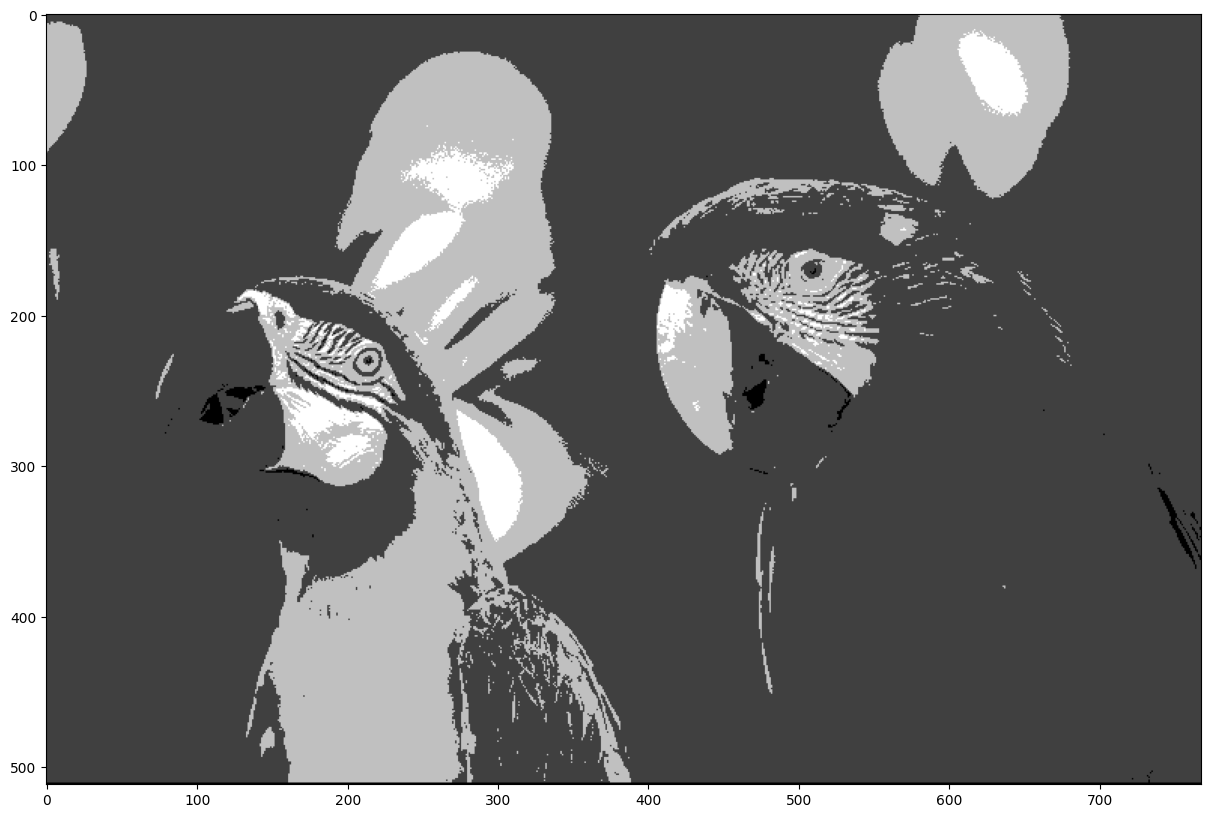

In [167]:
# Show quantized image (don't forget to cast back to uint8)
quantized_show = quantized.astype(np.uint8)
plt.imshow(quantized_show)

In [168]:
def psnr(original, quantized, prnt=True) -> Tuple[float, float]:
    """
    Compute image quality metrics between two images of equal size.

    Metrics:
    --------
    - PSNR (Peak Signal-to-Noise Ratio, in dB):
      Measures the ratio between the maximum possible pixel value
      (signal) and the mean squared error (noise).
      Higher PSNR = better image quality.

    - MSE (Mean Squared Error):
      Average squared difference between original and quantized images.
      Lower MSE = better image quality.

    Parameters
    ----------
    original : np.ndarray
        Original reference image.
    quantized : np.ndarray
        Distorted or quantized image to compare against the original.
    prnt : bool, optional
        If True, prints PSNR and MSE values (default=True).

    Returns
    -------
    psnr_value : float
        Peak Signal-to-Noise Ratio in dB.
    mse : float
        Mean Squared Error.
    """
    assert original.shape == quantized.shape, "Input images must have the same dimensions."
    # convert to float32 for safety
    original = original.astype(np.float32)
    quantized = quantized.astype(np.float32)

    mse = np.mean((original - quantized) ** 2)
    if mse == 0:
        return float("inf"), 0.0  # identical images

    max_pixel = 255.0
    psnr_value = 10 * np.log10((max_pixel ** 2) / mse)

    if prnt:
        print(f'Average quantization error         (PSNR): {psnr_value:.2f} dB')
        print(f'Average squared quantization error  (MSE): {mse:.2f}')

    return psnr_value, mse

In [169]:
# Compute average squared quantization error (PSNR)
avg_quant_error, mse = psnr(img, quantized)

Average quantization error         (PSNR): 14.83 dB
Average squared quantization error  (MSE): 2140.30


#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

In [176]:
def floyd_steinberg_dither(img: np.ndarray, colors: np.ndarray) -> np.ndarray:
    """
    Floyd–Steinberg error-diffusion dithering to a given palette.

    # Floyd–Steinberg kernel (for reference):
    # [ [0, 0, 7],
    #   [3, 5, 1] ] / 16

    Parameters
    ----------
    img : (H, W, C) uint8
        Source RGB image.
    colors : (K, C) uint8
        Target palette (each row is a colour).

    Returns
    -------
    dithered : (H, W, C) uint8
        Dithered image using the palette.
    """
    palette = colors.astype(np.float32)
    img_tmp = np.copy(img)
    img_tmp = img_tmp.astype(np.float32) # + add: float32 for error accumulation
    dithering = np.zeros_like(img)

    for r in range(1, rows - 1):
        for c in range(1, cols - 1):
            # Extract the original pixel value
            pixel = img_tmp[r, c, :]

            # Find the closest color from the palette (using absolute value/Euclidean distance)
            # Note: You may need more than one line of code here
            diffs = palette - pixel
            dists = np.linalg.norm(diffs, axis=1)
            new_pixel = colors[int(np.argmin(dists))]

            # Compute quantization error
            quant_error = pixel - new_pixel.astype(np.float32)

            # Diffuse the quantization error according to the FS diffusion matrix
            # Note: You may need more than one line of code here

            img_tmp[r,   c+1, :] += quant_error * (7/16)
            img_tmp[r-1, c-1, :] += quant_error * (3/16)
            img_tmp[r+1, c,   :] += quant_error * (5/16)
            img_tmp[r+1, c+1, :] += quant_error * (1/16)

            # Apply dithering
            dithering[r, c, :] = new_pixel

    return dithering.astype(np.uint8)


In [177]:
# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img)
img_tmp = img_tmp.astype(np.float32) # + add: float32 for error accumulation
dithering = np.zeros_like(img)
dithering = floyd_steinberg_dither(img, colors)
# Floyd–Steinberg kernel (for reference):
# [ [0, 0, 7],
#   [3, 5, 1] ] / 16

# for r in range(1, rows - 1):
#     for c in range(1, cols - 1):
#         # Extract the original pixel value
#         pixel = img_tmp[r, c, :]
#
#         # Find the closest color from the palette (using absolute value/Euclidean distance)
#         # Note: You may need more than one line of code here
#         diffs = palette - pixel
#         dists = np.linalg.norm(diffs, axis=1)
#         new_pixel = colors[int(np.argmin(dists))]
#
#         # Compute quantization error
#         quant_error = pixel - new_pixel.astype(np.float32)
#
#         # Diffuse the quantization error according to the FS diffusion matrix
#         # Note: You may need more than one line of code here
#
#         img_tmp[r,   c+1, :] += quant_error * (7/16)
#         img_tmp[r-1, c-1, :] += quant_error * (3/16)
#         img_tmp[r+1, c,   :] += quant_error * (5/16)
#         img_tmp[r+1, c+1, :] += quant_error * (1/16)
#
#         # Apply dithering
#         dithering[r, c, :] = new_pixel

(np.float64(-0.5), np.float64(767.5), np.float64(511.5), np.float64(-0.5))

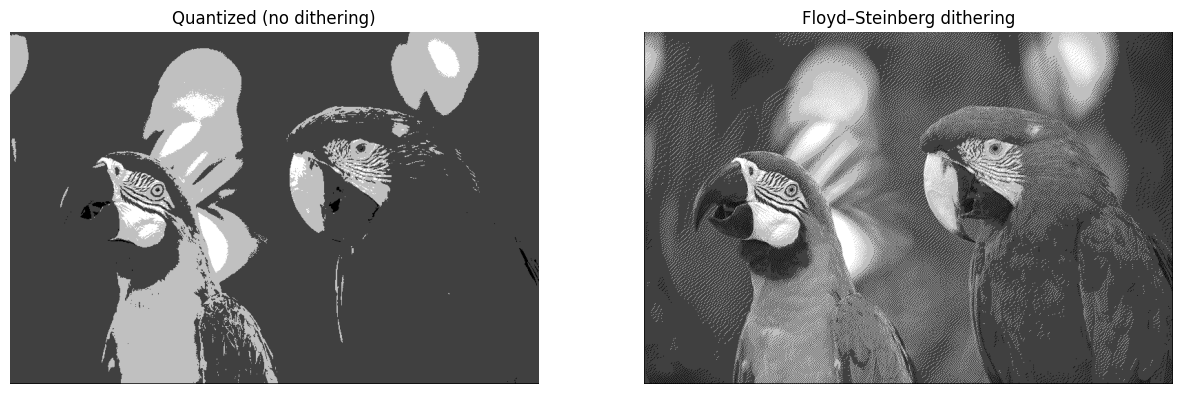

In [178]:
# Show quantized image (don't forget to cast back to uint8)

quantized_show = quantized.astype(np.uint8)
dithering_show = dithering.astype(np.uint8)

plt.subplot(121); plt.imshow(quantized_show);  plt.title("Quantized (no dithering)"); plt.axis("off")
plt.subplot(122); plt.imshow(dithering_show);  plt.title("Floyd–Steinberg dithering"); plt.axis("off")
# plt.show()

In [179]:
# Compute average quantization error for dithered image
# avg_dith_error, mse  = psnr(img_show, dithering_show)
psnr(img, quantized)
psnr(img, dithering)

Average quantization error         (PSNR): 14.83 dB
Average squared quantization error  (MSE): 2140.30
Average quantization error         (PSNR): 13.27 dB
Average squared quantization error  (MSE): 3060.97


(np.float32(13.272208), np.float32(3060.9731))

### Questions
**Q1. Which image has higher quantization error? Optimally quantized or dithered?**
- The **dithered** image has higher quantization error (higher MSE, lower PSNR).

**Q2. Which image looks better to you?**
- The **dithered** image looks better perceptually—error diffusion creates smoother gradients even though pixel-wise error is larger.

**Q3. Can you repeat the same process using only two colours: black and white? Show me :-)**
- **Yes.** Replace the palette with just two colours `[[0,0,0], [255,255,255]]` and rerun the quantization and FS dithering steps.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(np.float64(-0.5), np.float64(767.5), np.float64(511.5), np.float64(-0.5))

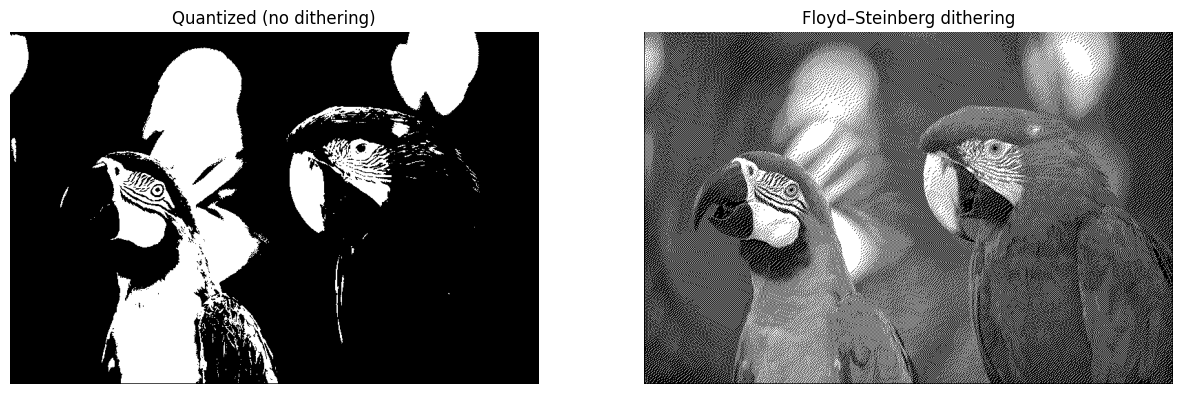

In [182]:

quantized_show = quantize_to_palette(img, colors_bw)
dithering_show = floyd_steinberg_dither(img, colors_bw)

plt.subplot(121); plt.imshow(quantized_show);  plt.title("Quantized (no dithering)"); plt.axis("off")
plt.subplot(122); plt.imshow(dithering_show);  plt.title("Floyd–Steinberg dithering"); plt.axis("off")

### Bonus Points

Repeat the homework using a diffrerent image pallette. For instance, you can use an optimal colour
pallette that we can calculate via k-means algorithm. The following snippet of code will give you the 16
optimal colours for your original image.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=16).fit(np.reshape(img, (-1, 3)))
colors = kmeans.cluster_centers_

Apply FS dithering the same way you did before.
* How does the result look like to you?
* What happens if we use 32 colours?
* And what happens if we use 256 colours?